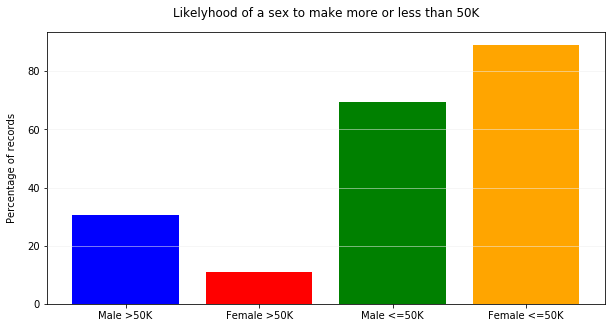

In [20]:
import matplotlib.pyplot as plt
import sqlite3 
import pandas as pd
import numpy as np

df = pd.read_csv("adult.data.txt", header=None, delimiter=', ', engine='python', names=["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]);

# index 0 - hours per week, 1 - >=50k, 2 - < 50k, 3 num of records
total = {"Male": [0, 0, 0, 0], "Female": [0, 0, 0, 0]}

for index, row in df.iterrows():
    record = total[row["sex"]]
    
    record[0] = record[0] + row["hours-per-week"]
    if row["income"] == ">50K":
        record[1] = record[1] + 1
    if row["income"] == "<=50K":
        record[2] = record[2] + 1
        
    record[3] = record[3] + 1

    
    
def format(pct):
    return "{:.1f}%".format(pct)

plt.rcParams['figure.figsize'] = [10, 5]

def calcPcnt(a, b):
    return a * 100.0 / b 

plt.bar(range(4), [calcPcnt(total["Male"][1], total["Male"][3]), calcPcnt(total["Female"][1], total["Female"][3]), calcPcnt(total["Male"][2], total["Male"][3]), calcPcnt(total["Female"][2], total["Female"][3])], color=['blue', 'red', 'green', 'orange'])

x = np.arange(4)
plt.xticks(x, ["Male >50K", "Female >50K", "Male <=50K", "Female <=50K"])
plt.grid(color='#EEEEEE', linestyle='-', linewidth=0.5, axis='y')
plt.rc('axes', axisbelow=False)

plt.ylabel('Percentage of records', labelpad=10)
plt.title('Likelyhood of a sex to make more or less than 50K', pad=15)
plt.show()